# Additional Exercise: Mushroom Dataset ID3

In [9]:
import csv

path = "/kaggle/input/datasets/organizations/uciml/mushroom-classification/mushrooms.csv"

columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
    "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type",
    "veil-color", "ring-number", "ring-type", "spore-print-color",
    "population", "habitat"
 ]

def load_mushroom_csv(file_path):
    with open(file_path, newline="") as f:
        reader = csv.reader(f)
        rows = [row for row in reader if row]
    if not rows:
        return []
    header = [item.strip().lower() for item in rows[0]]
    if "class" in header:
        with open(file_path, newline="") as f:
            dict_reader = csv.DictReader(f)
            data_rows = []
            for row in dict_reader:
                cleaned = {key.strip(): value.strip() for key, value in row.items()}
                data_rows.append(cleaned)
            return data_rows
    data_rows = [dict(zip(columns, row)) for row in rows]
    return data_rows

data = load_mushroom_csv(path)

sample_size = 200
data = data[:sample_size]

target = "class"
features = [col for col in columns if col != target]

In [10]:
import math
from collections import Counter

def entropy(rows, target_key):
    counts = Counter(row[target_key] for row in rows)
    total = len(rows)
    return -sum((count / total) * math.log2(count / total) for count in counts.values())

def information_gain(rows, feature, target_key):
    total_entropy = entropy(rows, target_key)
    total = len(rows)
    partitions = {}
    for row in rows:
        partitions.setdefault(row[feature], []).append(row)
    remainder = sum((len(subset) / total) * entropy(subset, target_key) for subset in partitions.values())
    return total_entropy - remainder

def majority_class(rows, target_key):
    counts = Counter(row[target_key] for row in rows)
    return max(counts.items(), key=lambda item: item[1])[0]

def build_tree(rows, feature_list, target_key, max_depth=None, depth=0):
    labels = set(row[target_key] for row in rows)
    if len(labels) == 1:
        return {"label": next(iter(labels))}
    if not feature_list or (max_depth is not None and depth >= max_depth):
        return {"label": majority_class(rows, target_key)}
    best_feature = max(feature_list, key=lambda f: information_gain(rows, f, target_key))
    tree = {"feature": best_feature, "nodes": {}}
    values = sorted(set(row[best_feature] for row in rows))
    for value in values:
        subset = [row for row in rows if row[best_feature] == value]
        remaining = [f for f in feature_list if f != best_feature]
        tree["nodes"][value] = build_tree(subset, remaining, target_key, max_depth, depth + 1)
    return tree

def print_tree(tree, indent=""):
    if "label" in tree:
        print(indent + "=> " + tree["label"])
        return
    print(indent + tree["feature"])
    for value, subtree in tree["nodes"].items():
        print(indent + f"- {value}:")
        print_tree(subtree, indent + "  " )

tree = build_tree(data, features, target, max_depth=3)
print_tree(tree)

odor
- a:
  => e
- l:
  => e
- n:
  => e
- p:
  => p


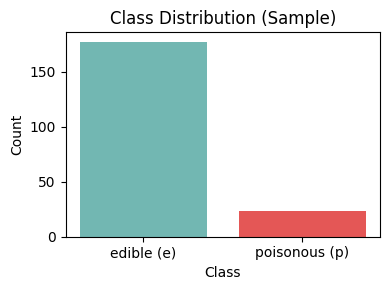

In [11]:
import matplotlib.pyplot as plt

counts = Counter(row[target] for row in data)
labels = ["edible (e)", "poisonous (p)"]
values = [counts.get("e", 0), counts.get("p", 0)]

plt.figure(figsize=(4, 3))
plt.bar(labels, values, color=["#72B7B2", "#E45756"])
plt.title("Class Distribution (Sample)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()